# 01 · scRNA-seq Analysis
**Dataset:** GEO GSE166635 — HCC tumor (HCC2) and adjacent normal tissue (HCC1)

This notebook runs the complete single-cell RNA-seq pipeline from raw MTX files
to annotated cells and differentially expressed genes.

| Step | What happens |
|------|-------------|
| Preprocessing | Load MTX, QC metrics, filter cells, normalise, select HVGs |
| Clustering | PCA → UMAP → Leiden at 4 resolutions |
| Annotation | CellTypist + ScType (R) + SingleR (R) + 4-way majority vote |
| DEA | Wilcoxon rank-sum tumor vs normal, volcano plot |
| GSEA | clusterProfiler (R): GO-BP/MF/CC + KEGG |

**Prerequisites:**  
- `python scripts/data_download.py` (downloads ~204 MB from GEO)  
- `Rscript env/r_packages.R` (installs Seurat, SingleR, celldex, ScType)

**Output:** `data/processed/dea_results.csv` — input for notebook 02


## Setup

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "paths.py").exists():
            return p
    raise FileNotFoundError("paths.py not found — run: python scripts/data_download.py")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(REPO_ROOT / "scripts") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "scripts"))

from paths import REPO_ROOT, RAW_DIR, PROC_DIR, FIGURES_DIR, TABLES_DIR, MODELS_DIR, REPORTS_DIR
print(f"Repo root : {REPO_ROOT}")
print(f"Raw data  : {RAW_DIR}")
print(f"Processed : {PROC_DIR}")

Repo root : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD
Raw data  : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\raw
Processed : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed


In [2]:
import scanpy as sc
from utils.scrna_functions import (load_samples, qc_metrics, filter_cells,
                              normalize, select_hvg, save_adata,
                              run_pca, run_umap, run_leiden,
                              run_celltypist, prep_seurat_object, pull_r_col,
                              marker_score_clusters, majority_vote, MARKER_SETS)
from utils.dea_functions  import run_wilcoxon, plot_volcano, export_dea
from utils.gsea_functions import prepare_ranked_list, run_gsea_r, print_gsea_summary
import matplotlib.pyplot as plt
%matplotlib inline
print(f"scanpy: {sc.__version__}")

scanpy: 1.11.5


In [3]:
# ── Configuration — edit here if needed ──────────────────────────────────────
# Preprocessing
MIN_GENES   = 200
MAX_GENES   = 2500
MAX_MT_PCT  = 5
N_TOP_GENES = 2000

# Clustering
N_NEIGHBORS = 15
N_PCS       = 10
RESOLUTIONS = (0.3, 0.5, 1.0, 2.0)

# Annotation
LEIDEN_COL  = "leiden_res_0.50"
CELLTYPIST_MODE  = "high"   # "high" = coarse (~30 types)  |  "low" = fine-grained (~200 subtypes)  |  "both" = run both

# DEA
PADJ_THRESH   = 0.05
LOG2FC_THRESH = 1.0
GROUP         = "tumor (HCC2)"
GROUPBY       = "sample"

## 1 · R environment (required for annotation and GSEA)

In [4]:
import os, sys

# ── R environment — update R_HOME if needed ───────────────────────────────────
# macOS  : /Library/Frameworks/R.framework/Resources
# Linux  : /usr/lib/R
# Windows: r"C:\Program Files\R\R-4.5.3"
R_HOME = r"C:\Program Files\R\R-4.5.3"
if R_HOME:
    os.environ["R_HOME"] = R_HOME
    if sys.platform == "win32":
        os.environ["PATH"] = os.path.join(R_HOME,"bin","x64") + ";" + os.environ["PATH"]

%load_ext rpy2.ipython
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import default_converter
import anndata2ri
print("R environment ready")

R environment ready


---
## 2 · Preprocessing

In [5]:
adata = load_samples(RAW_DIR)

Loaded: 25189 cells × 33694 genes
sample
normal (HCC1)    16077
tumor (HCC2)      9112


In [6]:
# Capture raw cell counts BEFORE QC filtering (required by generate_scrna_report)
_counts = adata.obs["sample"].value_counts()
n_raw_hcc1 = int(_counts.get("HCC1", _counts.get("normal (HCC1)", 0)))
n_raw_hcc2 = int(_counts.get("HCC2", _counts.get("tumor (HCC2)",  0)))
print(f"Raw counts — HCC1: {n_raw_hcc1:,}  HCC2: {n_raw_hcc2:,}")

Raw counts — HCC1: 16,077  HCC2: 9,112


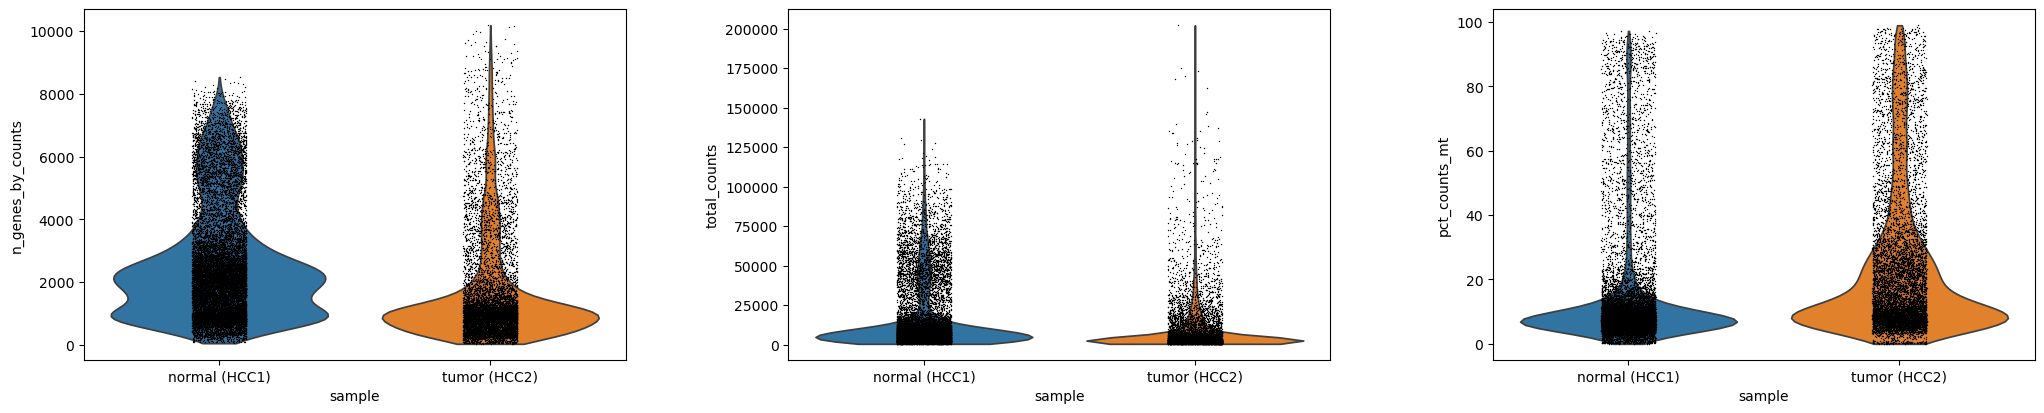

In [7]:
adata = qc_metrics(adata)
sc.pl.violin(adata, ["n_genes_by_counts","total_counts","pct_counts_mt"],
             groupby="sample", multi_panel=True, show=False)
plt.savefig(FIGURES_DIR / "qc_violin.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

In [8]:
adata = filter_cells(adata, MIN_GENES, MAX_GENES, MAX_MT_PCT)

Before filtering : 25189 cells
After min_genes  : 24832 cells
After max_genes  : 16981 cells
After MT filter  : 2795 cells


In [9]:
adata = normalize(adata)

Max expression after log1p: 8.88


In [10]:
adata = select_hvg(adata, n_top_genes=N_TOP_GENES, batch_key="sample")

HVGs selected: 2000


In [11]:
save_adata(adata, PROC_DIR / "adata_processed.h5ad")

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed\adata_processed.h5ad  (2795 cells × 33694 genes)


---
## 3 · Clustering

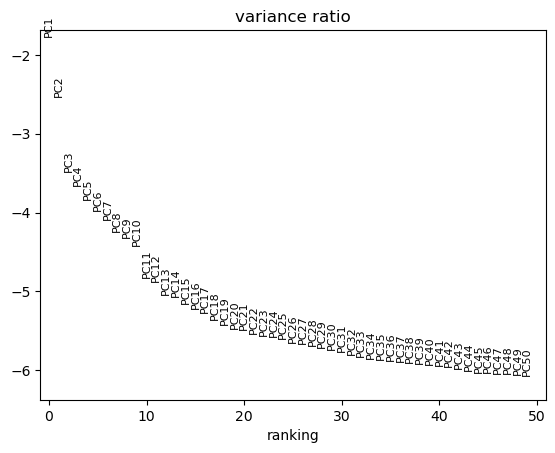

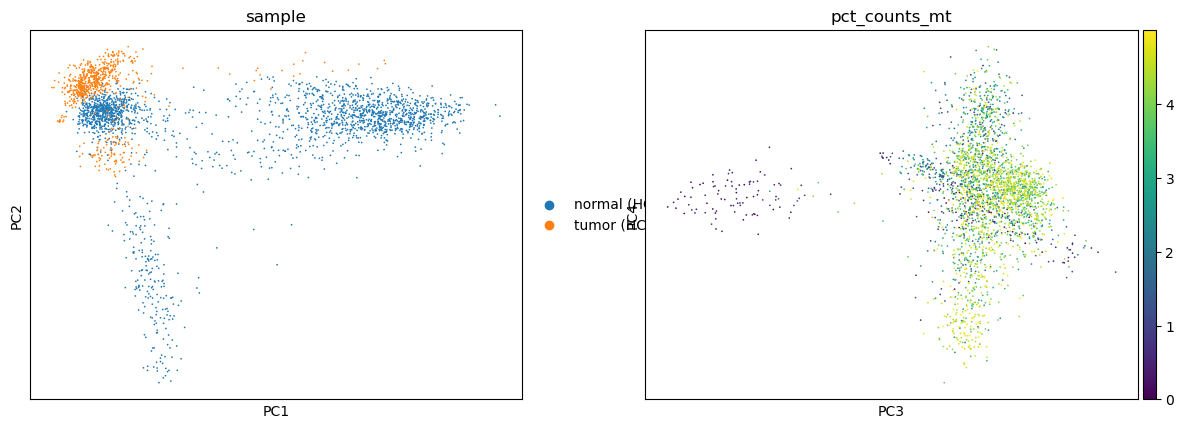

In [12]:
adata = run_pca(adata)

UMAP computed  (n_neighbors=15, n_pcs=10)


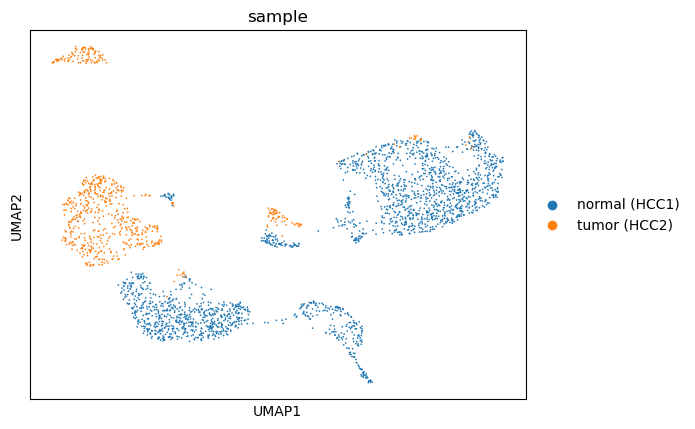

In [13]:
adata = run_umap(adata, n_neighbors=N_NEIGHBORS, n_pcs=N_PCS)
sc.pl.umap(adata, color="sample", size=6, show=False)
plt.savefig(FIGURES_DIR / "umap_samplewise.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

  res=0.30  →  10 clusters
  res=0.50  →  14 clusters
  res=1.00  →  20 clusters
  res=2.00  →  25 clusters


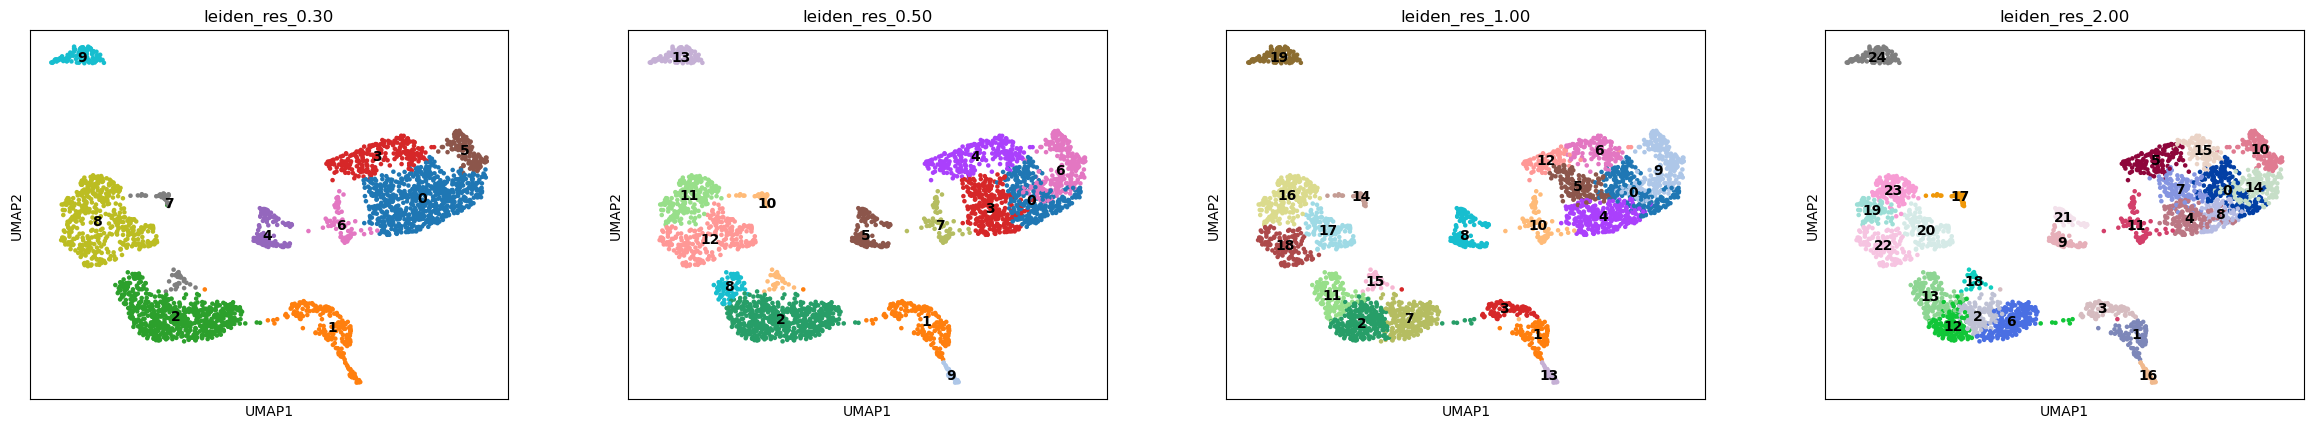

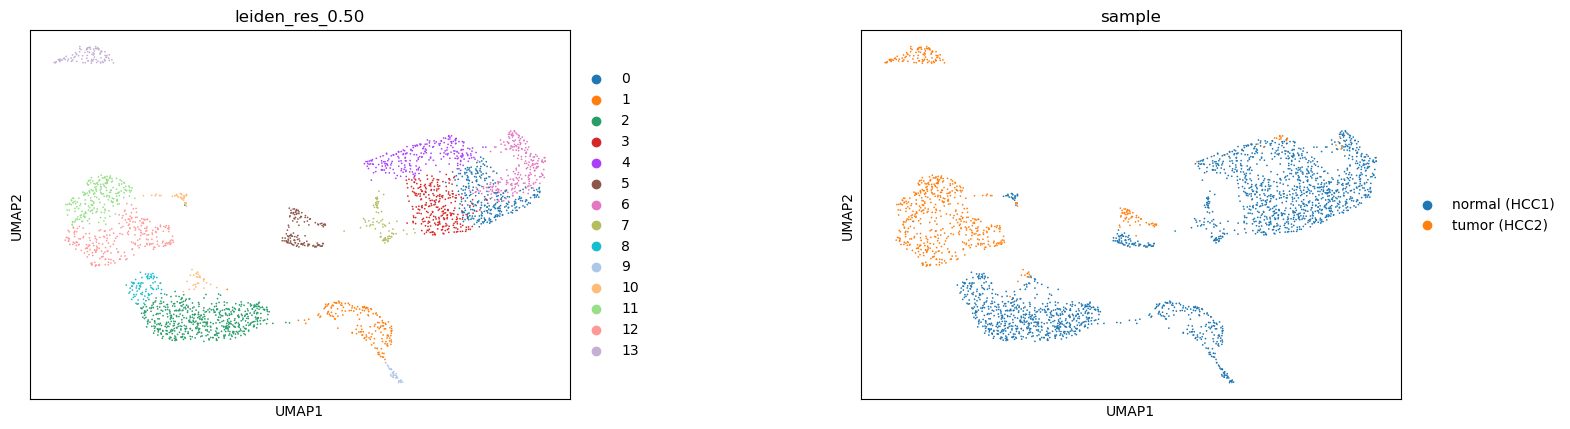

In [14]:
adata = run_leiden(adata, resolutions=RESOLUTIONS)
sc.pl.umap(adata, color=["leiden_res_0.50","sample"], wspace=0.4, size=6, show=False)
plt.savefig(FIGURES_DIR / "umap_leiden.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

In [15]:
save_adata(adata, PROC_DIR / "adata_clustered.h5ad")

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed\adata_clustered.h5ad  (2795 cells × 33694 genes)


---
## 4 · Cell-type annotation

### 4a · CellTypist

CellTypist mode: high


📂 Storing models in C:\Users\shoko\.celltypist\data\models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_High.pkl (file exists)
🔬 Input data has 2795 cells and 33694 genes
🔗 Matching reference genes in the model
🧬 5656 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


  coarse types (High model): 7
CellTypist mode: low


📂 Storing models in C:\Users\shoko\.celltypist\data\models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)
🔬 Input data has 2795 cells and 33694 genes
🔗 Matching reference genes in the model
🧬 5656 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


  fine types   (Low model) : 11


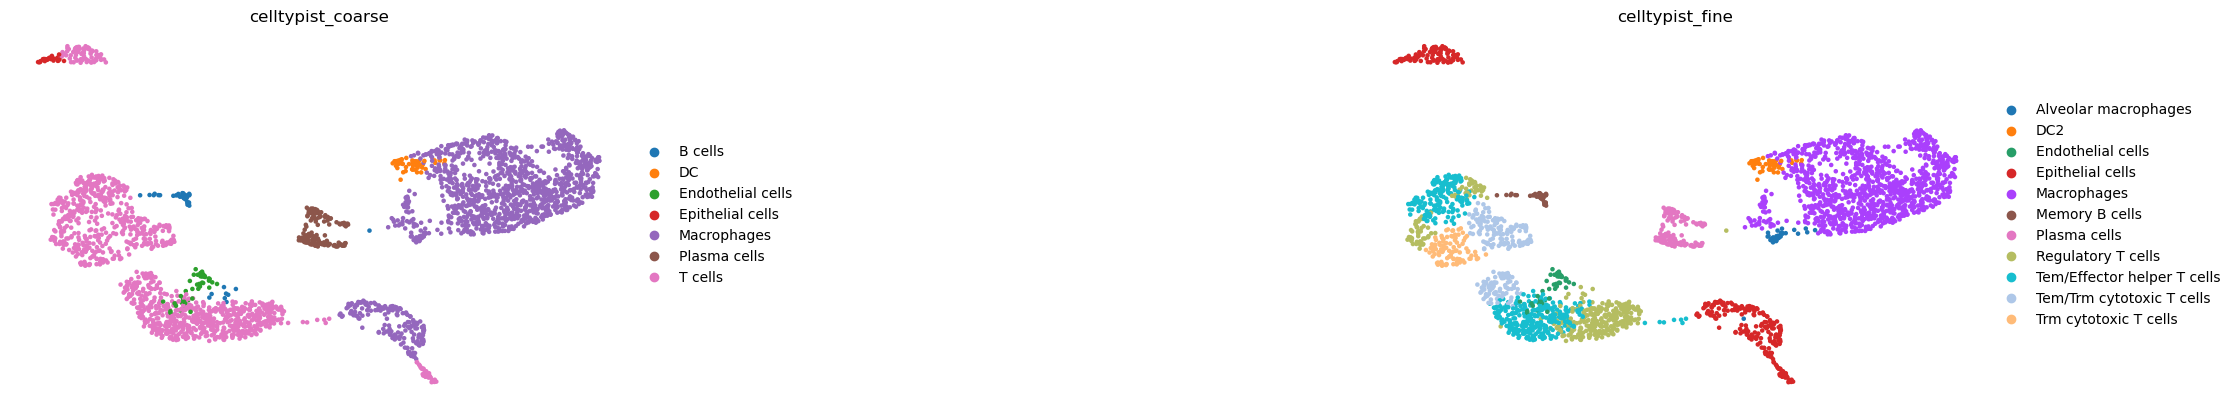

In [16]:
adata = run_celltypist(adata, mode="high")
adata = run_celltypist(adata, mode="low")
sc.pl.umap(adata, color=["celltypist_coarse","celltypist_fine"],
           frameon=False, wspace=1, show=False)
plt.savefig(FIGURES_DIR / "umap_celltypist.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

### 4b · ScType (liver-specific database)

In [17]:
%%R
library(Seurat); library(dplyr); library(HGNChelper); library(openxlsx)
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/gene_sets_prepare.R")
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/sctype_score_.R")
gs_list <- gene_sets_prepare(
    "https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/ScTypeDB_full.xlsx",
    "Liver")

Loading required package: SeuratObject
Loading required package: sp

Attaching package: 'SeuratObject'

The following objects are masked from 'package:base':

    intersect, t


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Please cite our software :) 
 
 Sehyun Oh et al. HGNChelper: identification and correction of invalid gene symbols for human and mouse. F1000Research 2020, 9:1493. DOI: https://doi.org/10.12688/f1000research.28033.1 
 
 Type `citation('HGNChelper')` for a BibTeX entry.
In addition: Warning messages:
1: 
   File C:\Users\shoko\OneDrive\Documents/.Renviron contains invalid line(s)
tools40"
   They were ignored
 
2: In checkGeneSymbols(markers_all) :
  Human gene symbols should be all upper-case except for the 'orf' in open reading frames. The case of some letters was corrected.
3: In checkGeneSymbols(markers_all) : x co

In [18]:
adata_seurat = prep_seurat_object(adata, ro, default_converter, anndata2ri)

adata_seurat pushed to R global environment


In [19]:
%%R
expr_matrix <- assay(adata_seurat, "logcounts")
es_max <- sctype_score(scRNAseqData=expr_matrix, scaled=TRUE,
                       gs=gs_list$gs_positive, gs2=gs_list$gs_negative)
clusters <- colData(adata_seurat)$leiden_res_0.50
cl_results <- lapply(unique(clusters), function(cl) {
    cells <- which(clusters == cl)
    es    <- sort(rowSums(es_max[, cells, drop=FALSE]), decreasing=TRUE)
    data.frame(cluster=cl, cell_type=names(es)[1], score=es[1])
}) |> dplyr::bind_rows()
cluster_to_type <- setNames(cl_results$cell_type, cl_results$cluster)
colData(adata_seurat)$sctype_cell_type <- cluster_to_type[as.character(clusters)]
print(cl_results)

                         cluster              cell_type      score
Kupffer cells...1              0          Kupffer cells 1068.09619
Hepatocytes...2                1            Hepatocytes  870.94599
Immune system cells...3        2    Immune system cells 1101.11147
Kupffer cells...4              3          Kupffer cells  981.09913
Kupffer cells...5              4          Kupffer cells  863.70445
Hepatocytes...6                5            Hepatocytes   85.61424
Kupffer cells...7              6          Kupffer cells 1267.42108
Kupffer cells...8              7          Kupffer cells  213.93541
Immune system cells...9        8    Immune system cells  147.08436
Hepatocytes...10               9            Hepatocytes  289.45241
Hepatic stellate cells        10 Hepatic stellate cells  111.35504
Immune system cells...12      11    Immune system cells  346.57091
Immune system cells...13      12    Immune system cells  477.50144
Cholangiocytes                13         Cholangiocytes  384.4

In addition: Warning message:
In sctype_score(scRNAseqData = expr_matrix, scaled = TRUE, gs = gs_list$gs_positive,  :
  scRNAseqData doesn't seem to be a matrix


Pulled 'sctype_cell_type' → adata.obs['sctype_cell_type']
sctype_cell_type
Kupffer cells             1158
Immune system cells       1147
Hepatocytes                331
Cholangiocytes              98
Hepatic stellate cells      61


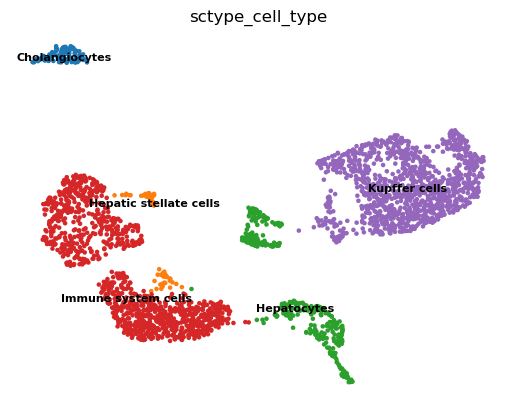

In [20]:
adata = pull_r_col(adata, ro, default_converter, pandas2ri,
                   col_name="sctype_cell_type", obs_col="sctype_cell_type")
sc.pl.umap(adata, color="sctype_cell_type", legend_loc="on data",
           legend_fontsize=8, frameon=False, show=False)
plt.savefig(FIGURES_DIR / "umap_sctype.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

### 4c · SingleR (HPCA reference)

In [21]:
%%R
library(SingleR); library(celldex)
ref_hpca  <- HumanPrimaryCellAtlasData()
pred_hpca <- SingleR(test=adata_seurat, ref=ref_hpca,
                     labels=ref_hpca$label.main)
colData(adata_seurat)$SingleR_HPCA <- pred_hpca$pruned.labels


Attaching package: 'celldex'

The following objects are masked from 'package:SingleR':

    BlueprintEncodeData, DatabaseImmuneCellExpressionData,
    HumanPrimaryCellAtlasData, ImmGenData, MonacoImmuneData,
    MouseRNAseqData, NovershternHematopoieticData



In [22]:
adata = pull_r_col(adata, ro, default_converter, pandas2ri,
                   col_name="SingleR_HPCA", obs_col="SingleR_HPCA")

Pulled 'SingleR_HPCA' → adata.obs['SingleR_HPCA']
SingleR_HPCA
T_cells                1051
Macrophage              678
Monocyte                224
Hepatocytes             216
DC                      208
B_cell                  136
NK_cell                  95
Epithelial_cells         91
NA_character_            36
Neutrophils              13
Endothelial_cells        12
Pre-B_cell_CD34-          7
CMP                       7
Tissue_stem_cells         7
Smooth_muscle_cells       4
Erythroblast              2
Neurons                   2
Fibroblasts               1
GMP                       1
BM                        1
Chondrocytes              1
Pro-B_cell_CD34+          1
Pro-Myelocyte             1


### 4d · Marker scoring & majority vote

In [23]:
score_df = marker_score_clusters(adata, leiden_col=LEIDEN_COL, marker_sets=MARKER_SETS)

Best cell type by marker score per cluster:
cluster
0      Macrophage
1      Hepatocyte
2          T_cell
3      Macrophage
4        Monocyte
5     Plasma_cell
6      Macrophage
7      Macrophage
8      CD8_T_cell
9      Hepatocyte
10         B_cell
11         T_cell
12         T_cell
13       Monocyte


In [24]:
adata, vote_df = majority_vote(adata, score_df, leiden_col=LEIDEN_COL)

Cluster → final label:
                 n_cells                  final_label
leiden_res_0.50                                      
0                    297                   Macrophage
1                    173                  Hepatocytes
2                    585  Tem/Effector helper T cells
3                    289                   Macrophage
4                    248                     Monocyte
5                    124                 Plasma cells
6                    247                   Macrophage
7                     77                   Macrophage
8                     78    Tem/Trm cytotoxic T cells
9                     34                  Hepatocytes
10                    61                       B_cell
11                   220  Tem/Effector helper T cells
12                   264    Tem/Trm cytotoxic T cells
13                    98             Epithelial cells


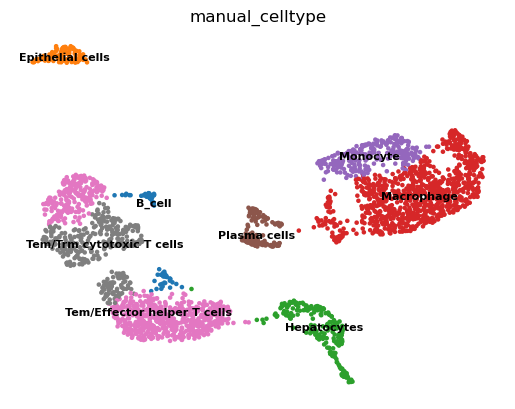

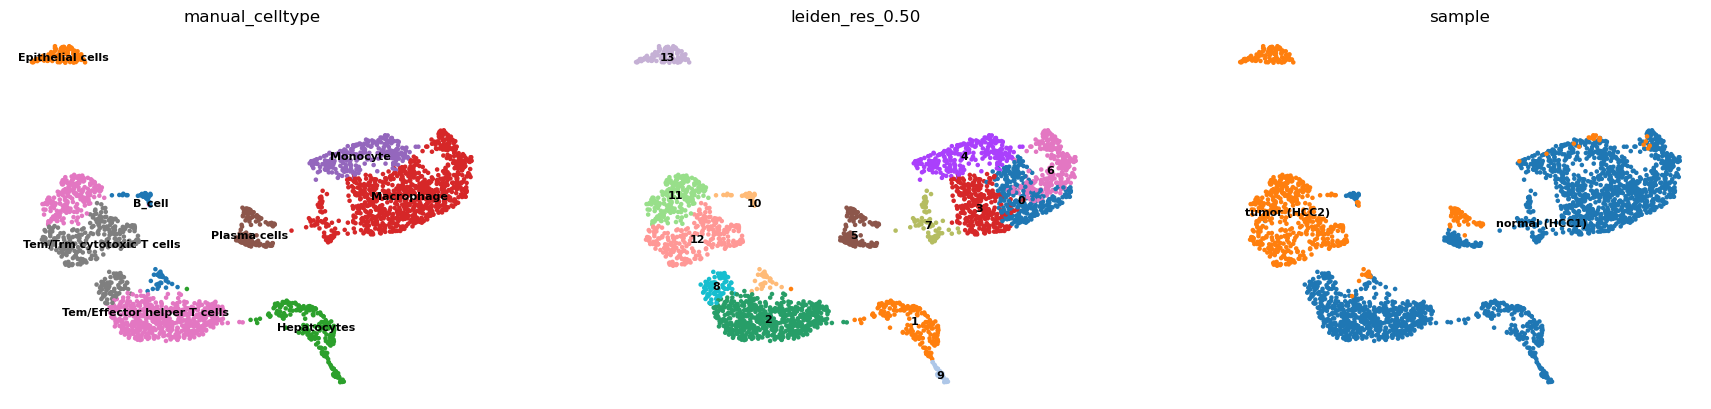

In [25]:
# Save the three panels individually so the report can embed each one
# Annotated cell types
sc.pl.umap(adata, color="manual_celltype",
           legend_loc="on data", legend_fontsize=8, frameon=False, show=False)
plt.savefig(FIGURES_DIR / "umap_annotation.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close("all")

# Combined 3-panel figure for quick visual inspection in the notebook
sc.pl.umap(adata, color=["manual_celltype", "leiden_res_0.50", "sample"],
           legend_loc="on data", legend_fontsize=8, frameon=False, ncols=3)

In [26]:
# Ensure all columns in adata.obs are of supported types
for col in adata.obs.columns:
    if adata.obs[col].dtype == "object":
        adata.obs[col] = adata.obs[col].astype(str)
    elif adata.obs[col].dtype.name == "category":
        adata.obs[col] = adata.obs[col].astype(str).astype("category")

In [27]:
save_adata(adata, PROC_DIR / "adata_annotated.h5ad")

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed\adata_annotated.h5ad  (2795 cells × 33694 genes)


---
## 5 · Differential expression analysis

In [28]:
sig, de_results = run_wilcoxon(adata,
                               groupby=GROUPBY, group=GROUP,
                               padj_thresh=PADJ_THRESH,
                               log2fc_thresh=LOG2FC_THRESH)
sig.head(10)

Total DEGs    : 1385
Upregulated   : 335
Downregulated : 1050


,gene,scores,log2FC,pvalue,adj_pvalue,regulation
0,RPS26,26.308933,1.991955,1.515576e-152,7.295115e-149,up
1,XIST,23.464739,31.180847,9.349445e-122,2.625168e-118,up
2,MALAT1,20.834894,1.089554,2.089721e-96,3.200503e-93,up
3,CREM,19.406971,2.918553,6.738461e-84,7.829163e-81,up
4,JUND,18.446568,1.322786,5.556331e-76,5.349000e-73,up
6,RP11-138A9.2,16.519718,3.155438,2.646311e-61,1.621178e-58,up
7,HLA-C,16.483912,1.089220,4.788466e-61,2.881117e-58,up
8,ZFP36L2,16.010973,2.108820,1.071225e-57,5.552903e-55,up
9,BTG1,15.975739,1.349612,1.886050e-57,9.484859e-55,up
10,SRSF7,15.574635,1.745543,1.082697e-54,5.211486e-52,up


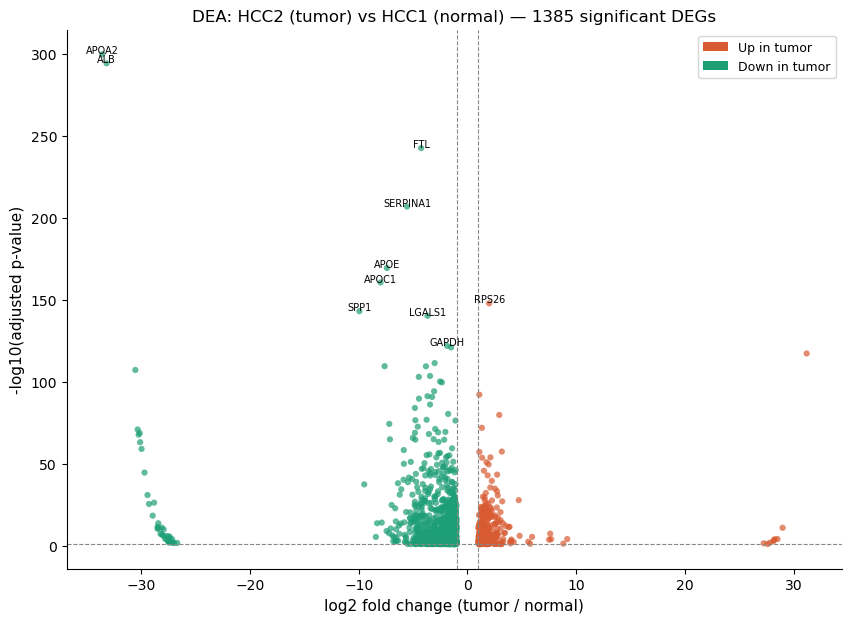

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/volcano_plot.png


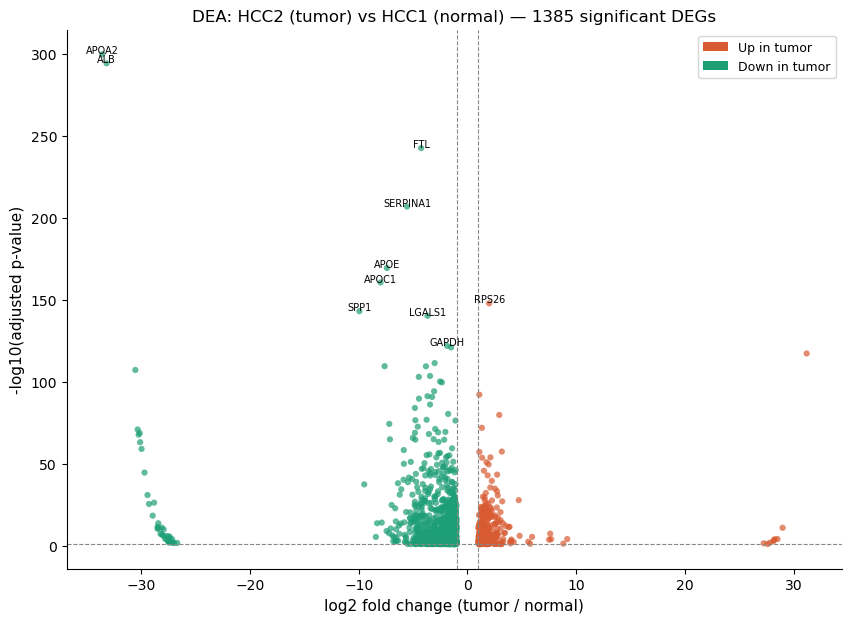

In [29]:
plot_volcano(sig, FIGURES_DIR)

In [30]:
export_dea(sig, PROC_DIR)

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed\dea_results.csv  (1385 DEGs)

Top 5 upregulated:
   gene    log2FC    adj_pvalue
   XIST 31.180847 2.625168e-118
  OLFM4 28.968952  4.820013e-12
  ADH1C 28.503433  3.367689e-05
   TFF2 28.247526  4.383444e-05
CEACAM6 28.181561  1.653879e-04

Top 5 downregulated:
  gene     log2FC    adj_pvalue
 APOA2 -33.587166  0.000000e+00
   ALB -33.181702 3.627433e-295
RPS4Y1 -30.532921 2.993306e-108
 FABP1 -30.319868  5.665009e-72
  AHSG -30.232588  7.987003e-69


---
## 6 · GSEA

In [31]:
%%R
pkgs <- c("clusterProfiler","org.Hs.eg.db","enrichplot","DOSE","ggplot2")
if (!requireNamespace("BiocManager", quietly=TRUE))
    install.packages("BiocManager", repos="https://cloud.r-project.org")
for (pkg in pkgs)
    if (!requireNamespace(pkg, quietly=TRUE))
        BiocManager::install(pkg, ask=FALSE, update=FALSE)
suppressPackageStartupMessages({
    library(clusterProfiler); library(org.Hs.eg.db)
    library(enrichplot);      library(ggplot2)
})
cat("GSEA packages ready\n")

GSEA packages ready


In [32]:
ranked = prepare_ranked_list(PROC_DIR / "dea_results.csv", PROC_DIR)

Ranked list: 1385 genes → C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\data\processed\ranked_genes_log2fc.tsv


In [33]:
run_gsea_r(ro, PROC_DIR, FIGURES_DIR, TABLES_DIR)

R callback write-console: 'select()' returned 1:1 mapping between keys and columns
  


Genes mapped to Entrez: 1314 / 1385
Running GO-BP...
Running GO-MF...
Running GO-CC...
Running KEGG...


R callback write-console: Reading KEGG annotation online: "https://rest.kegg.jp/link/hsa/pathway"...
  
R callback write-console: Reading KEGG annotation online: "https://rest.kegg.jp/list/pathway/hsa"...
  



GO-BP : 120 terms
GO-MF : 10 terms
GO-CC : 16 terms
KEGG  : 2 pathways
Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/gsea_go_biological_process.png
Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/gsea_go_molecular_function.png
Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/gsea_go_cellular_component.png
Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/gsea_kegg_pathways.png


R callback write-console: Picking joint bandwidth of 2.99
  


Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/gsea_ridgeplot_bp.png
Saved theme: Lipid_metabolism
Saved theme: Immune_regulation
CSV tables saved.


R callback write-console: In addition:   
R callback write-console: Warning messages:
  
R callback write-console: 1:   
R callback write-console: In bitr(rnk$SYMBOL, fromType = "SYMBOL", toType = "ENTREZID", OrgDb = org.Hs.eg.db) :  
R callback write-console: 
   
R callback write-console:  5.13% of input gene IDs are fail to map...
  
R callback write-console: 2:   
R callback write-console: In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :  
R callback write-console: 
   
R callback write-console:  For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.
  
R callback write-console: 3:   
R callback write-console: In fgseaMultilevel(pathways = pathways, stats = stats, minSize = minSize,  :  
R callback write-console: 
   
R callback write-console:  There were 2 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval


✓ GSEA complete


In [34]:
print_gsea_summary(TABLES_DIR)

── GSEA results summary ──

  GO-BP: 120 enriched terms
                  Description       NES  p.adjust
establishment of localization -1.319186  0.041753
                    transport -1.335020  0.041753
              immune response -1.373900  0.046330

  GO-MF: 10 enriched terms
               Description       NES  p.adjust
    small molecule binding -1.347953  0.029355
signaling receptor binding -1.603512  0.013556
             lipid binding -1.869436  0.000858

  GO-CC: 16 enriched terms
                             Description       NES  p.adjust
                   extracellular exosome -1.396657   0.01603
                 extracellular organelle -1.399694   0.01603
extracellular membrane-bounded organelle -1.399694   0.01603

  KEGG: 2 enriched terms
           Description       NES  p.adjust
PPAR signaling pathway -2.011785  0.002554
Cholesterol metabolism -2.097698  0.001062

── HCC-relevant pathway hits (GO-BP) ──

  Lipid metabolism: 29 terms
    response to lipid -1.52959

---
## Report
Generates a self-contained HTML summary for biology experts.

In [ ]:
from utils.report_functions import generate_scrna_report

report_path = generate_scrna_report(
    # results
    adata=adata, sig=sig, vote_df=vote_df, score_df=score_df, ranked=ranked,
    # raw cell counts (captured before QC filtering)
    n_raw_hcc1=n_raw_hcc1, n_raw_hcc2=n_raw_hcc2,
    # configuration
    min_genes=MIN_GENES, max_genes=MAX_GENES, max_mt_pct=MAX_MT_PCT,
    n_top_genes=N_TOP_GENES, n_neighbors=N_NEIGHBORS, n_pcs=N_PCS,
    resolutions=RESOLUTIONS, leiden_col=LEIDEN_COL,
    padj_thresh=PADJ_THRESH, log2fc_thresh=LOG2FC_THRESH, group=GROUP,
    # paths
    figures_dir=FIGURES_DIR, tables_dir=TABLES_DIR, reports_dir=REPORTS_DIR,
)
print(f"\nOpen in browser: {report_path}")

  Report saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\reports\01_scrna_analysis_report.html

Open in browser: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\reports\01_scrna_analysis_report.html


: 